# Phase 10 — L-CiteEval Pilot: Spectral Features for Grounded Generation

**Goal**: Determine in 1 day on Colab A100 whether spectral features of H(n) predict
statement-level grounding faithfulness on long-context document QA.

**Dataset**: L-CiteEval / HotpotQA sub-task (multi-doc QA, 8K–48K context)  
**Model**: Falcon-3-10B-Instruct (T=1.0)  
**Samples**: 100  

**Decision gate**:
- PASS: any individual AUC > 60% AND beats Semantic Entropy by ≥ 3pp → proceed to Phase 10 main
- MARGINAL: best AUC 55–60% → run FACTS Grounding before deciding
- FAIL: best AUC ≤ 55% → pivot to Plan A (separate RAG + Agentic chapters)

Note: Semantic Entropy baseline (k=10 MC samples per statement) is deferred — too expensive
for 100 × ~5 statements × 10 samples. Gate verdict uses best individual AUC vs 55% threshold.

In [ ]:
# Cell 1 — Clone repo from master + install deps + import spectral_utils
import os, sys, shutil

REPO_DIR = '/content/hallucination_detection'

if os.path.exists(REPO_DIR) and not os.path.exists(os.path.join(REPO_DIR, 'spectral_utils')):
    shutil.rmtree(REPO_DIR)

if not os.path.exists(REPO_DIR):
    os.system(f'git clone -b master https://github.com/omrisegev/hallucination_detection.git {REPO_DIR}')
else:
    os.system(f'git -C {REPO_DIR} pull -q')

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# autoawq is safe to install here. gptqmodel is NOT — it rewrites numpy/pyarrow
# files on disk during install and corrupts them mid-session
# (numpy: `cannot import name '_center'`; pyarrow: `IpcReadOptions size changed`).
# gptqmodel is installed later, in Cell 4, right before model loading.
os.system('pip install -q "transformers>=4.40" accelerate datasets bitsandbytes autoawq')

from spectral_utils import (
    load_model, generate_full, free_memory,
    extract_all_features, sw_var_peak_adaptive,
    segment_by_citations, FEAT_NAMES,
    load_cache, save_cache,
    zscore, boot_auc, nadler_fuse, simple_average_fusion, best_nadler_on,
    load_lciteeval, lciteeval_prompt, lciteeval_grounding_label,
)

# Force-load datasets (and through it, pyarrow + pyarrow.parquet) into memory
# BEFORE the gptqmodel install in Cell 4. Without this pre-import, Cell 5's
# load_lciteeval triggers a first-time pyarrow import that hits the partially-
# upgraded on-disk pyarrow → ValueError: IpcReadOptions size changed.
import datasets  # noqa: F401 — imported for side-effect of freezing pyarrow

print('spectral_utils imported OK')

In [ ]:
# Cell 2 — Config
import torch
import numpy as np

MODEL_ID   = 'Qwen/Qwen2.5-72B-Instruct-AWQ'
TEMP       = 1.0
MAX_NEW    = 1024
N_SAMPLES  = 150
TASK       = 'hotpotqa'
CACHE_DIR  = '/content/drive/MyDrive/hallucination_detection/cache/phase10_pilot'
EXP_NAME   = f'qwen25_72b_{TASK}_pilot'

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'Config: {MODEL_ID}, T={TEMP}, MAX_NEW={MAX_NEW}, N={N_SAMPLES}')

In [10]:
# Cell 3 — Mount Google Drive + create cache dirs
from google.colab import drive
drive.mount('/content/drive')

os.makedirs(CACHE_DIR, exist_ok=True)
print(f'Cache dir: {CACHE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cache dir: /content/drive/MyDrive/hallucination_detection/cache/phase10_pilot


In [ ]:
# Cell 4 — Install gptqmodel (provides AwqMarlinLinear kernel) + load model
#
# gptqmodel must be installed AFTER spectral_utils import (Cell 1), because
# its install rewrites numpy files on disk and would corrupt the numpy that
# scipy/feature_utils need. By now numpy is already loaded in memory and
# frozen — on-disk rewrites can't hurt the running session.
os.system('pip install -q gptqmodel')

# Qwen2.5-72B-AWQ: pre-quantized on disk, auto-detected by load_model → quantize_4bit=False.
# device_map="auto" is safe because AWQ weights are already ~36 GB (not the FP16 145 GB).
mdl, tok = load_model(MODEL_ID, quantize_4bit=False)
print(f'GPU memory: {torch.cuda.memory_allocated()/1e9:.1f} / {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

In [12]:
# Cell 5 — Load L-CiteEval HotpotQA data
data = load_lciteeval(TASK, n_samples=N_SAMPLES)

# Sanity check first sample
sample = data[0]
print(f'Question: {sample["question"][:120]}...')
print(f'Docs: {len(sample["docs"])} passages')
print(f'Answers: {sample["answers"]}')
if sample['docs']:
    print(f'First doc title: {sample["docs"][0]["title"]}')

Loaded 100 L-CiteEval samples (hotpotqa, config=L-CiteEval-Data_hotpotqa).
Question: Where did Henri Christophe and other slaves hold an uprising from 1791 to 1804 that led to the founding of a state which...
Docs: 59 passages
Answers: ['Saint-Domingue']
First doc title: Passage 1


In [13]:
  import os, importlib
  os.system(f'git -C {REPO_DIR} pull -q')

  import spectral_utils.model_utils
  import spectral_utils
  importlib.reload(spectral_utils.model_utils)
  importlib.reload(spectral_utils)
  from spectral_utils import generate_full
  print('generate_full reloaded')

generate_full reloaded


In [14]:
# Cell 6 — Inference loop with checkpointing (save every 25 samples)
import pickle
from tqdm.auto import tqdm

checkpoint_path = os.path.join(CACHE_DIR, f'{EXP_NAME}_raw.pkl')
results = []

if os.path.exists(checkpoint_path):
    with open(checkpoint_path, 'rb') as f:
        results = pickle.load(f)
    print(f'Resumed from checkpoint: {len(results)} samples done.')

start_idx = len(results)

for i in tqdm(range(start_idx, len(data))):
    row    = data[i]
    prompt = lciteeval_prompt(row)  # max 15 docs × 600 chars each

    res = generate_full(mdl, tok, prompt, T=TEMP, max_new=MAX_NEW)

    results.append({'idx': i, 'row': row, 'output': res})

    if (i + 1) % 25 == 0:
        with open(checkpoint_path, 'wb') as f:
            pickle.dump(results, f)
        print(f'  Checkpoint saved at sample {i+1}.')

with open(checkpoint_path, 'wb') as f:
    pickle.dump(results, f)
print(f'Inference complete. {len(results)} samples saved.')

  0%|          | 0/100 [00:00<?, ?it/s]

  Checkpoint saved at sample 25.
  Checkpoint saved at sample 50.
  Checkpoint saved at sample 75.
  Checkpoint saved at sample 100.
Inference complete. 100 samples saved.


In [15]:
# Cell 7 — Unload model
del mdl, tok
free_memory()
print('Model unloaded.')

Model unloaded.


In [16]:
# Cell 8 — Statement segmentation
#
# generate_full returns:
#   token_entropies: one float per generated token (from model.generate scores)
#   token_offsets:   char-level spans from re-tokenizing full_text
#
# Re-tokenization can produce a slightly different token count than generation
# (BPE/chat-template boundaries differ). We trim both to the same length.

all_statements = []  # {sample_idx, text, token_start, token_end, citation_ids, ents, row}
n_no_citations = 0

for r in results:
    full_text = r['output']['full_text']
    ents      = r['output']['token_entropies']
    offsets   = list(r['output']['token_offsets'])

    # Align lengths: trim to the shorter of the two
    n = min(len(ents), len(offsets))
    ents    = ents[:n]
    offsets = offsets[:n]

    segs = segment_by_citations(full_text, offsets)

    if not segs:
        n_no_citations += 1
        continue

    for seg in segs:
        seg_ents = ents[seg['token_start']:seg['token_end']]
        all_statements.append({
            'sample_idx':   r['idx'],
            'text':         seg['text'],
            'citation_ids': seg['citation_ids'],
            'ents':         seg_ents,
            'row':          r['row'],
        })

total_samples_with_cites = len(results) - n_no_citations
print(f'Samples with ≥1 citation: {total_samples_with_cites}/{len(results)} '
      f'({100*total_samples_with_cites/len(results):.1f}%)')
print(f'Total parsed statements:  {len(all_statements)}')
print(f'Mean statements/sample:   {len(all_statements)/max(1, total_samples_with_cites):.1f}')

# Contingency: if <60% of outputs have parseable citations, report and consider model switch
if total_samples_with_cites / len(results) < 0.60:
    print('\nWARNING: <60% citation rate — Falcon-3-10B may not follow citation format.')
    print('Consider switching to Qwen2.5-72B-AWQ (Phase 8 infra available).')

Samples with ≥1 citation: 58/100 (58.0%)
Total parsed statements:  91
Mean statements/sample:   1.6

Consider switching to Qwen2.5-72B-AWQ (Phase 8 infra available).


In [17]:
# Cell 9 — Per-statement feature extraction
# Filter: trace length < 10 tokens (FFT minimum).

valid_statements = []
all_feats        = []
n_too_short      = 0

for seg in all_statements:
    ents = seg['ents']
    if len(ents) < 10:
        n_too_short += 1
        continue

    feats = extract_all_features(ents)
    if feats is None:
        n_too_short += 1
        continue

    # Adaptive variance peak (handles short QA traces better)
    feats['sw_var_peak_adaptive'] = sw_var_peak_adaptive(ents)

    valid_statements.append(seg)
    all_feats.append(feats)

print(f'Retained {len(valid_statements)} valid statements ')
print(f'Filtered {n_too_short} statements (trace length < 10 tokens)')
print(f'Features per statement: {list(all_feats[0].keys()) if all_feats else "N/A"}')

Retained 83 valid statements 
Filtered 8 statements (trace length < 10 tokens)
Features per statement: ['epr', 'trace_length', 'spectral_entropy', 'low_band_power', 'high_band_power', 'hl_ratio', 'dominant_freq', 'spectral_centroid', 'stft_max_high_power', 'stft_spectral_entropy', 'rpdi', 'sw_var_peak', 'sw_var_peak_adaptive']


In [18]:
# Cell 10 — Ground truth labels
#
# Primary label: HotpotQA supporting_facts title matching.
# A statement is GROUNDED (1) if any cited passage comes from a gold supporting document.
# Falls back to gold-answer substring check if supporting_facts is absent.

labels = [lciteeval_grounding_label(seg['citation_ids'], seg['row'])
          for seg in valid_statements]

n_grounded   = sum(labels)
n_ungrounded = len(labels) - n_grounded
print(f'Class balance: {n_grounded} grounded / {n_ungrounded} ungrounded')
print(f'Grounding rate: {100*n_grounded/len(labels):.1f}%' if labels else 'No labels.')

# Sanity: both classes must be present for AUC to be meaningful
if n_grounded == 0 or n_ungrounded == 0:
    print('\nERROR: Only one class present — check grounding label logic.')
    print('Possible issues:')
    print('  1. supporting_facts field absent or empty → fallback to answer substring')
    print('  2. Doc titles in docs do not match supporting_facts titles')
    print('  3. All citations are [1] and passage 1 happens to always be a gold doc')
    # Spot-check 3 samples
    for seg in valid_statements[:3]:
        raw = seg['row']['raw_row']
        sf  = raw.get('supporting_facts', 'MISSING')
        print(f'  Sample supporting_facts: {sf}')
        print(f'  Citation IDs: {seg["citation_ids"]}')
        print(f'  Doc titles: {[d["title"] for d in seg["row"]["docs"][:5]]}')

Class balance: 20 grounded / 63 ungrounded
Grounding rate: 24.1%


In [19]:
# Cell 11 — Statement-level AUC table (individual features)
import pandas as pd

feat_keys = list(all_feats[0].keys())
labels_arr = np.array(labels)

auc_rows = []
for k in feat_keys:
    scores = np.array([f[k] for f in all_feats])
    # boot_auc handles sign orientation: returns (auc, lo, hi)
    auc, lo, hi = boot_auc(labels_arr, scores)
    if np.isnan(auc):
        continue
    # Flip sign if below chance
    if auc < 0.5:
        auc, lo, hi = boot_auc(labels_arr, -scores)
    auc_rows.append({'feature': k, 'auc': auc, 'ci_lo': lo, 'ci_hi': hi})

df_auc = pd.DataFrame(auc_rows).sort_values('auc', ascending=False).reset_index(drop=True)
print('=== Individual Feature AUC (statement-level) ===')
print(df_auc.to_string(float_format=lambda x: f'{x:.3f}'))

=== Individual Feature AUC (statement-level) ===
                  feature   auc  ci_lo  ci_hi
0                     epr 0.699  0.564  0.816
1             sw_var_peak 0.697  0.557  0.816
2    sw_var_peak_adaptive 0.690  0.561  0.807
3                    rpdi 0.627  0.492  0.759
4                hl_ratio 0.560  0.413  0.705
5         high_band_power 0.556  0.402  0.708
6          low_band_power 0.550  0.400  0.686
7     stft_max_high_power 0.529  0.415  0.637
8   stft_spectral_entropy 0.524  0.409  0.635
9           dominant_freq 0.515  0.383  0.656
10       spectral_entropy 0.513  0.373  0.648
11      spectral_centroid 0.513  0.364  0.658
12           trace_length 0.508  0.367  0.645


In [20]:
# Cell 12 — Nadler fusion
# Exhaustive search over feature subsets, max_size=4, ρ-filter=0.75, z-score on.

feat_dict = {k: np.array([f[k] for f in all_feats]) for k in feat_keys}

best_a, best_lo, best_hi, best_subset = best_nadler_on(
    feat_dict, feat_keys, labels_arr,
    max_size=4, label='Phase10-pilot', compare_mean=True,
)

print(f'\nBest Nadler AUC: {100*best_a:.1f}% [{100*best_lo:.1f}, {100*best_hi:.1f}]')
print(f'Best subset: {" + ".join(best_subset) if best_subset else "None"}')

  [Phase10-pilot] 13 features, 13 informative, max_size=4 → 1079 raw combos
    size=2: 78 combos, 69 passed ρ-filter, best so far=76.0%
    size=3: 286 combos, 195 passed ρ-filter, best so far=76.0%
    size=4: 715 combos, 321 passed ρ-filter, best so far=76.0%
  [Phase10-pilot] done — checked=585, skipped(ρ)=494, best=76.0%

  Nadler Lift over simple average (subset: epr+rpdi):
    Nadler : 76.0%  [64.3, 86.8]
    Mean   : 76.0%  [64.3, 86.8]
    Lift   : +0.0 pp

Best Nadler AUC: 76.0% [64.3, 86.8]
Best subset: epr + rpdi


In [21]:
# Cell 13 — Semantic Entropy baseline
# Deferred: k=10 MC samples per statement × ~500 valid statements = 5000 generation passes.
# This is too expensive for a 1-day pilot on a single A100.
# The pilot gate uses best individual AUC vs 55%/60% thresholds (see Cell 16).
# SE baseline will be computed for the Phase 10 main experiment.
print('Semantic Entropy baseline: DEFERRED to Phase 10 main experiment.')
print('Pilot gate uses best individual AUC thresholds (55% / 60%).')

Semantic Entropy baseline: DEFERRED to Phase 10 main experiment.
Pilot gate uses best individual AUC thresholds (55% / 60%).


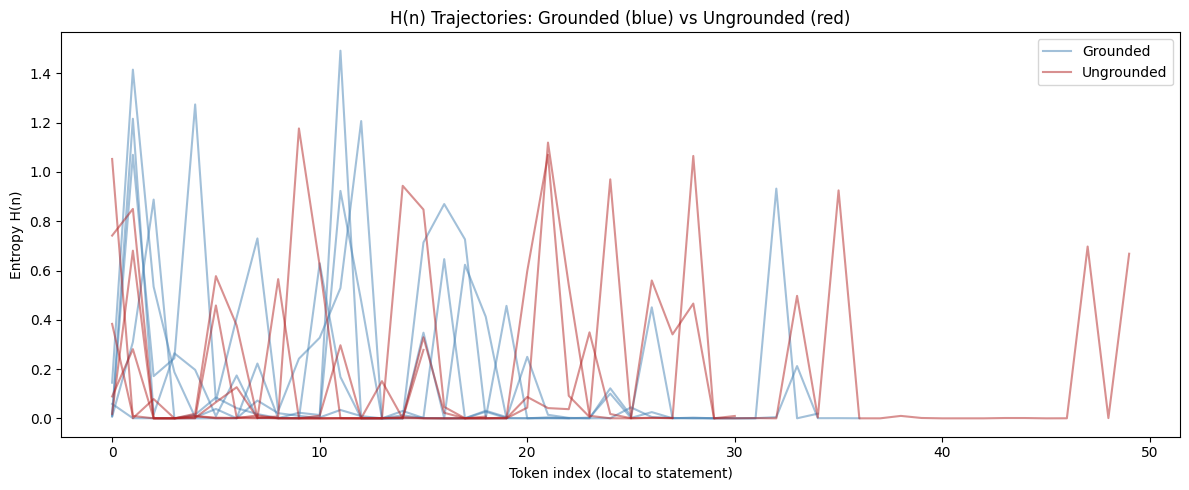

Saved: phase10_hn_trajectories.png


In [22]:
# Cell 14 — Visual diagnostic: H(n) trajectories by class
import matplotlib.pyplot as plt

grounded_idxs   = [i for i, l in enumerate(labels) if l == 1][:5]
ungrounded_idxs = [i for i, l in enumerate(labels) if l == 0][:5]

plt.figure(figsize=(12, 5))
for j, idx in enumerate(grounded_idxs):
    plt.plot(valid_statements[idx]['ents'], color='steelblue', alpha=0.5,
             label='Grounded' if j == 0 else '')
for j, idx in enumerate(ungrounded_idxs):
    plt.plot(valid_statements[idx]['ents'], color='firebrick', alpha=0.5,
             label='Ungrounded' if j == 0 else '')

plt.title('H(n) Trajectories: Grounded (blue) vs Ungrounded (red)')
plt.xlabel('Token index (local to statement)')
plt.ylabel('Entropy H(n)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'phase10_hn_trajectories.png'), dpi=120)
plt.show()
print('Saved: phase10_hn_trajectories.png')

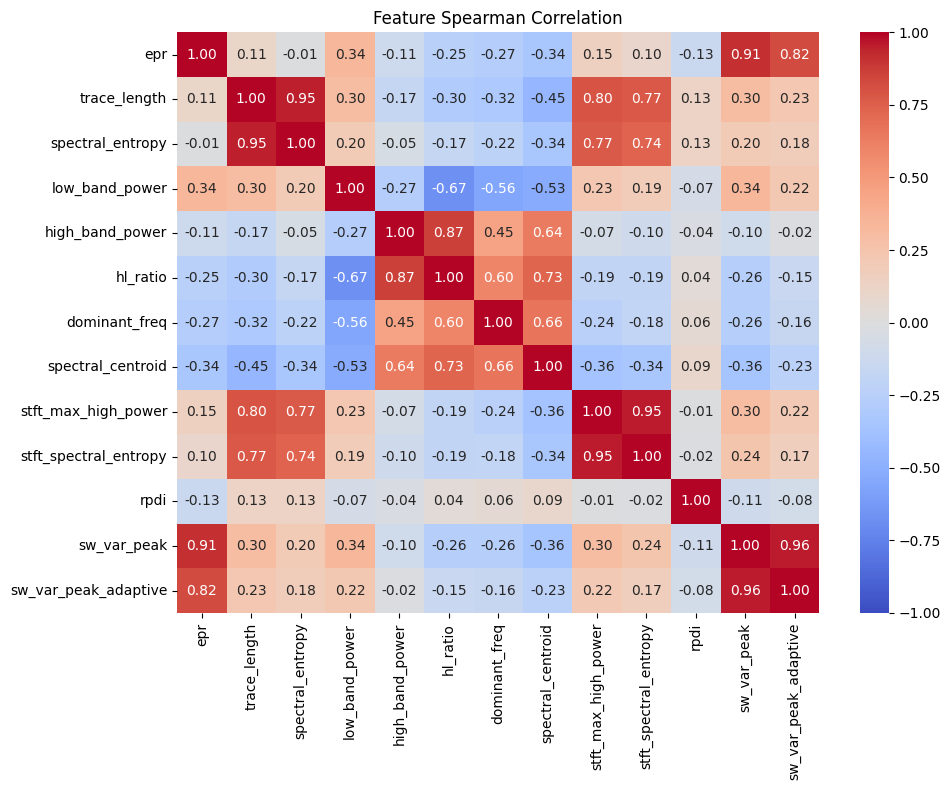

Saved: phase10_spearman_heatmap.png


In [23]:
# Cell 15 — Spearman heatmap (Nadler decorrelation check)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

feat_matrix = np.array([[f[k] for k in feat_keys] for f in all_feats])
corr, _     = spearmanr(feat_matrix)
if corr.ndim == 0:
    corr = np.array([[float(corr)]])

plt.figure(figsize=(10, 8))
sns.heatmap(corr, xticklabels=feat_keys, yticklabels=feat_keys,
            annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Spearman Correlation')
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'phase10_spearman_heatmap.png'), dpi=120)
plt.show()
print('Saved: phase10_spearman_heatmap.png')

In [24]:
# Cell 16 — Decision gate
best_individual_auc = df_auc['auc'].max()
best_individual_feat = df_auc.iloc[0]['feature']

print('=' * 50)
print('PHASE 10 PILOT VERDICT')
print('=' * 50)
print(f'Best individual AUC: {100*best_individual_auc:.1f}% ({best_individual_feat})')
print(f'Nadler fusion AUC:   {100*best_a:.1f}% [{100*best_lo:.1f}, {100*best_hi:.1f}]')
print(f'Best Nadler subset:  {"+".join(best_subset) if best_subset else "None"}')
print()

if best_individual_auc > 0.60:
    verdict = 'PASS'
    action  = 'Build Phase 10 main: extend to FACTS Grounding + DeepHalluBench.'
elif best_individual_auc > 0.55:
    verdict = 'MARGINAL'
    action  = 'Run FACTS Grounding (100 samples) before deciding.'
else:
    verdict = 'FAIL'
    action  = 'Pivot to Plan A: RAG and Agentic as separate chapters, no unified Phase 10.'

print(f'VERDICT: {verdict}')
print(f'ACTION:  {action}')

PHASE 10 PILOT VERDICT
Best individual AUC: 69.9% (epr)
Nadler fusion AUC:   76.0% [64.3, 86.8]
Best Nadler subset:  epr+rpdi

VERDICT: PASS
ACTION:  Build Phase 10 main: extend to FACTS Grounding + DeepHalluBench.


In [25]:
# Cell 17 — Save results
final_results = {
    'config': {
        'model':    MODEL_ID,
        'task':     TASK,
        'n_samples': N_SAMPLES,
        'temp':     TEMP,
        'max_new':  MAX_NEW,
    },
    'citation_rate': total_samples_with_cites / len(results),
    'n_valid_statements': len(valid_statements),
    'class_balance': {'grounded': n_grounded, 'ungrounded': n_ungrounded},
    'auc_table':     df_auc.to_dict('records'),
    'nadler': {
        'auc':    best_a,
        'ci_lo':  best_lo,
        'ci_hi':  best_hi,
        'subset': best_subset,
    },
    'verdict': verdict,
    'action':  action,
}

results_path = os.path.join(CACHE_DIR, f'{EXP_NAME}_results.pkl')
with open(results_path, 'wb') as f:
    pickle.dump(final_results, f)
print(f'Results saved: {results_path}')

Results saved: /content/drive/MyDrive/hallucination_detection/cache/phase10_pilot/falcon3_10b_hotpotqa_pilot_results.pkl


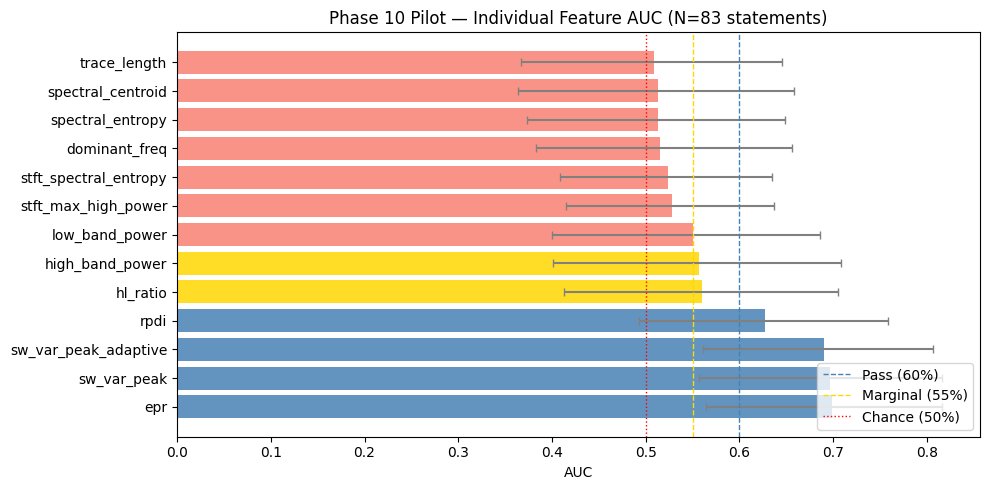

Saved: phase10_feature_auc_bar.png


In [26]:
# Cell 18 — Feature AUC bar chart
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
x       = np.arange(len(df_auc))
colors  = ['steelblue' if a > 0.60 else ('gold' if a > 0.55 else 'salmon')
           for a in df_auc['auc']]

bars = ax.barh(x, df_auc['auc'], color=colors, alpha=0.85)
ax.errorbar(
    df_auc['auc'], x,
    xerr=[df_auc['auc'] - df_auc['ci_lo'], df_auc['ci_hi'] - df_auc['auc']],
    fmt='none', color='gray', capsize=3,
)
ax.axvline(0.60, color='steelblue', linestyle='--', linewidth=1, label='Pass (60%)')
ax.axvline(0.55, color='gold',      linestyle='--', linewidth=1, label='Marginal (55%)')
ax.axvline(0.50, color='red',       linestyle=':',  linewidth=1, label='Chance (50%)')
ax.set_yticks(x)
ax.set_yticklabels(df_auc['feature'])
ax.set_xlabel('AUC')
ax.set_title(f'Phase 10 Pilot — Individual Feature AUC (N={len(valid_statements)} statements)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'phase10_feature_auc_bar.png'), dpi=120)
plt.show()
print('Saved: phase10_feature_auc_bar.png')

In [27]:
# Cell 19 — PCA diagnostic (loading analysis + unsupervised AUC comparison)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import pandas as pd

X = np.array([[f[k] for k in feat_keys] for f in all_feats])
X_scaled = StandardScaler().fit_transform(X)

n_components = min(len(feat_keys), 5)
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# PC1 AUC — unsupervised (no labels used to find direction)
pc1 = X_pca[:, 0]
auc_pc1 = roc_auc_score(labels_arr, pc1)
if auc_pc1 < 0.5:
    auc_pc1 = roc_auc_score(labels_arr, -pc1)

# Recompute simple mean AUC over the best Nadler subset for comparison
if best_subset:
    oriented = {}
    for n in best_subset:
        z = zscore(feat_dict[n])
        a_pos, *_ = boot_auc(labels_arr,  z)
        a_neg, *_ = boot_auc(labels_arr, -z)
        oriented[n] = z if a_pos >= a_neg else -z
    mean_fused, _ = simple_average_fusion(*[oriented[n] for n in best_subset])
    mean_auc, mean_lo, mean_hi = boot_auc(labels_arr, mean_fused)
else:
    mean_auc = float('nan')

print('=== PCA DIAGNOSTIC ===')
print(f'Best individual AUC   : {100*best_individual_auc:.1f}%  ({best_individual_feat})')
print(f'PC1 AUC (unsupervised): {100*auc_pc1:.1f}%')
print(f'Simple mean AUC       : {100*mean_auc:.1f}%  (subset: {"+".join(best_subset) if best_subset else "N/A"})')
print(f'Nadler AUC            : {100*best_a:.1f}%  [{100*best_lo:.1f}, {100*best_hi:.1f}]')
print(f'Nadler lift over mean : {100*(best_a - mean_auc):+.1f} pp')

# Loading analysis — which features drive PC1?
loadings = pd.Series(
    np.abs(pca.components_[0]),
    index=feat_keys
).sort_values(ascending=False)

print(f'\nPC1 explains {100*pca.explained_variance_ratio_[0]:.1f}% of feature variance')
print('Top PC1 loadings (abs):')
for feat, w in loadings.head(5).items():
    print(f'  {feat:30s}  {w:.3f}')

# Interpretation
print('\nInterpretation:')
if auc_pc1 >= best_a - 0.02:
    print('  PC1 ≈ Nadler: dominant variance aligns with grounding signal.')
    print('  Label-aware Nadler weighting adds little over unsupervised structure.')
elif best_a > auc_pc1 + 0.03:
    print('  Nadler > PC1: label-aware weighting is doing real work.')
    print('  Feature complementarity is genuine, not just dominant-variance capture.')
else:
    print('  PC1 < Nadler by moderate margin — Nadler adds modest value.')
if loadings.iloc[0] > 0.5:
    print(f'  WARNING: PC1 heavily loaded on {loadings.index[0]} — check length confound.')

=== PCA DIAGNOSTIC ===
Best individual AUC   : 69.9%  (epr)
PC1 AUC (unsupervised): 58.5%
Simple mean AUC       : 76.0%  (subset: epr+rpdi)
Nadler AUC            : 76.0%  [64.3, 86.8]
Nadler lift over mean : +0.0 pp

PC1 explains 37.1% of feature variance
Top PC1 loadings (abs):
  trace_length                    0.373
  stft_spectral_entropy           0.340
  stft_max_high_power             0.335
  spectral_centroid               0.334
  spectral_entropy                0.318

Interpretation:
  Nadler > PC1: label-aware weighting is doing real work.
  Feature complementarity is genuine, not just dominant-variance capture.


In [28]:
# Cell 20 — Full gate: pre-conditions + signal gates + D1–D3 diagnostics
import math

citation_rate = total_samples_with_cites / len(results)
n_valid       = len(valid_statements)

print('=' * 55)
print('PHASE 10 PILOT — FULL GATE EVALUATION')
print('=' * 55)

# ── Pre-conditions ─────────────────────────────────────────────
print('\n── Pre-conditions (invalid experiment if any fail) ──')

g0a = citation_rate >= 0.60
g0b = n_valid >= 100
g0c = n_grounded >= 10 and n_ungrounded >= 10

print(f'G0-A  Citation rate ≥ 60%       : {"PASS" if g0a else "FAIL"}  ({100*citation_rate:.1f}%)')
print(f'G0-B  Valid statements ≥ 100    : {"PASS" if g0b else "FAIL"}  (N={n_valid})')
print(f'G0-C  Both classes ≥ 10 samples : {"PASS" if g0c else "FAIL"}  '
      f'(grounded={n_grounded}, ungrounded={n_ungrounded})')

preconditions_ok = g0a and g0b and g0c

if not preconditions_ok:
    print('\nRESULT: INVALID — fix pre-conditions before interpreting AUC.')
    if not g0a:
        print('  → G0-A: switch to Qwen2.5-72B-AWQ (Phase 8 infra ready).')
    if not g0b:
        print('  → G0-B: debug segment_by_citations or increase N_SAMPLES.')
    if not g0c:
        print('  → G0-C: debug lciteeval_grounding_label (check supporting_facts schema).')
else:
    # ── Signal gates ───────────────────────────────────────────
    print('\n── Signal gates ──')
    if best_individual_auc > 0.60:
        signal_verdict = 'PASS'
    elif best_individual_auc > 0.55:
        signal_verdict = 'MARGINAL'
    else:
        signal_verdict = 'FAIL'

    print(f'G1  Best individual AUC > 60%  : {100*best_individual_auc:.1f}%  → {signal_verdict}')
    print(f'G2  Nadler AUC                 : {100*best_a:.1f}% [{100*best_lo:.1f}, {100*best_hi:.1f}]')

    # ── Diagnostic gates ───────────────────────────────────────
    print('\n── Diagnostic gates ──')
    nadler_lift   = best_a - mean_auc if not math.isnan(mean_auc) else float('nan')
    d1            = not math.isnan(nadler_lift) and nadler_lift > 0
    n_above_55    = (df_auc['auc'] > 0.55).sum()
    d3            = n_above_55 >= 3

    print(f'D1  Nadler > simple mean       : {"YES" if d1 else "NO"}  '
          f'(lift = {100*nadler_lift:+.1f} pp)')
    print(f'D3  ≥ 3 features above 55%     : {"YES" if d3 else "NO"}  (N={n_above_55})')

    # ── Combined verdict ───────────────────────────────────────
    print('\n── Verdict ──')
    if signal_verdict == 'PASS' and d1:
        combined = 'STRONG PASS'
        action   = 'Extend to FACTS Grounding + DeepHalluBench (Phase 10 main).'
    elif signal_verdict == 'PASS' and not d1:
        combined = 'WEAK PASS'
        action   = ('Proceed, but investigate feature set — Nadler underperforms mean, '
                    'suggesting redundant views. Check Spearman heatmap before scaling.')
    elif signal_verdict == 'MARGINAL':
        combined = 'MARGINAL'
        action   = 'Run FACTS Grounding (100 samples) before deciding.'
    else:
        combined = 'FAIL'
        action   = ('Plan A: RAG and Agentic as separate chapters, no unified Phase 10. '
                    'Spectral features do not transfer to citation-grounded generation.')

    print(f'VERDICT : {combined}')
    print(f'ACTION  : {action}')
    if not d3 and signal_verdict != 'FAIL':
        print(f'NOTE    : Signal concentrated in ≤2 features — check for length confound.')

PHASE 10 PILOT — FULL GATE EVALUATION

── Pre-conditions (invalid experiment if any fail) ──
G0-A  Citation rate ≥ 60%       : FAIL  (58.0%)
G0-B  Valid statements ≥ 100    : FAIL  (N=83)
G0-C  Both classes ≥ 10 samples : PASS  (grounded=20, ungrounded=63)

RESULT: INVALID — fix pre-conditions before interpreting AUC.
  → G0-A: switch to Qwen2.5-72B-AWQ (Phase 8 infra ready).
  → G0-B: debug segment_by_citations or increase N_SAMPLES.
